In [22]:
# generate metadata for each campaign's inference tiles

from pathlib import Path
import json
import rasterio

# PATHS
BASE = Path("/share/home/e2406751/Superresolution-TIR/data")
HR_DIR = BASE / "HR_downsampled"
ORIGINAL_METADATA = BASE / "processed/patches/metadata.json"
OUT_DIR = BASE / "inference_tiles"


HR_TILE = 256
HR_STRIDE = 128

def get_tile_origins(length, tile_size, stride):
    """
    Generate tile origins with overlap and ensure the final
    tile reaches the end of the raster.
    """
    if length <= tile_size:
        return [0]

    origins = list(range(0, length - tile_size + 1, stride))

    last_origin = length - tile_size

    if origins[-1] != last_origin:
        origins.append(last_origin)

    return origins


# LOAD ORIGINAL TRAINING METADATA
with open(ORIGINAL_METADATA, "r") as f:
    original_metadata = json.load(f)

print(f"Loaded original metadata: {len(original_metadata)} entries")


# EXTRACT CAMPAIGN-LEVEL TEMPORAL METADATA
campaign_temporal = {}
for tile_id, info in original_metadata.items():
    campaign = info["campaign"]
    temporal = {
        "hr_date": info["hr_date"],
        "lr_date": info["lr_date"],
        "date_gap_days": info["date_gap_days"],
        "hr_time": info["hr_time"],
        "lr_time": info["lr_time"],
        "time_gap_hours": info["time_gap_hours"],
    }

    if campaign not in campaign_temporal:
        campaign_temporal[campaign] = temporal
    else:
        # Verify that temporal metadata is consistent
        # across all patches belonging to this campaign.
        existing = campaign_temporal[campaign]
        if existing != temporal:
            raise ValueError(
                f"Temporal metadata is NOT consistent for campaign "
                f"{campaign}.\n"
                f"Existing: {existing}\n"
                f"Found in {tile_id}: {temporal}"
            )

print("\nCampaign temporal metadata:")

for campaign, temporal in sorted(campaign_temporal.items()):
    print(f"\n{campaign}")
    for key, value in temporal.items():
        print(f"  {key}: {value}")


# FIND HR CAMPAIGNS
hr_files = sorted(HR_DIR.glob("*.tif"))
print(f"\nFound {len(hr_files)} HR campaign files.")


# CREATE INFERENCE TILE METADATA
OUT_DIR.mkdir(parents=True, exist_ok=True)
total_tiles = 0
for hr_path in hr_files:
    campaign = hr_path.stem
    if campaign not in campaign_temporal:
        raise KeyError(
            f"No temporal metadata found for campaign: {campaign}"
        )
    with rasterio.open(hr_path) as src:
        height = src.height
        width = src.width
        transform = src.transform
        crs = src.crs
        rows = get_tile_origins(
            height,
            HR_TILE,
            HR_STRIDE
        )
        cols = get_tile_origins(
            width,
            HR_TILE,
            HR_STRIDE
        )
        metadata = {}
        tile_id = 0
        for row in rows:
            for col in cols:
                # Tile bounds
                left = transform.c + col * transform.a
                top = transform.f + row * transform.e
                right = left + HR_TILE * transform.a
                bottom = top + HR_TILE * transform.e
                tile_name = (
                    f"{campaign}_inf_r{row}_c{col}"
                )
                metadata[tile_name] = {
                    # Spatial / tile information
                    "campaign": campaign,
                    "tile_id": tile_id,
                    "row_origin": row,
                    "col_origin": col,
                    "tile_size_hr": HR_TILE,
                    "stride_hr": HR_STRIDE,
                    "crs": str(crs),
                    "bounds_2154": {
                        "left": left,
                        "right": right,
                        "top": top,
                        "bottom": bottom,
                    },
                    "hr_source": hr_path.name,
                    # Temporal information
                    "hr_date": campaign_temporal[campaign]["hr_date"],
                    "lr_date": campaign_temporal[campaign]["lr_date"],
                    "date_gap_days": campaign_temporal[campaign]["date_gap_days"],
                    "hr_time": campaign_temporal[campaign]["hr_time"],
                    "lr_time": campaign_temporal[campaign]["lr_time"],
                    "time_gap_hours": campaign_temporal[campaign]["time_gap_hours"],
                }

                tile_id += 1

        # Save campaign metadata
        campaign_dir = OUT_DIR / campaign
        campaign_dir.mkdir(parents=True, exist_ok=True)
        metadata_path = campaign_dir / "metadata.json"
        with open(metadata_path, "w") as f:
            json.dump(metadata, f, indent=2)
        total_tiles += len(metadata)

        print(
            f"{campaign}: "
            f"{height}×{width} HR pixels | "
            f"{len(rows)} rows × {len(cols)} cols = "
            f"{len(metadata)} inference tiles"
        )

print(f"\nTotal inference tiles: {total_tiles}")
print("Done.")

Loaded original metadata: 539 entries

Campaign temporal metadata:

BAS_2025
  hr_date: 2025-07-22
  lr_date: 2025-07-22
  date_gap_days: 0
  hr_time: 15.82
  lr_time: 10.48
  time_gap_hours: 5.33

BRC_2022
  hr_date: 2022-07-20
  lr_date: 2022-07-15
  date_gap_days: 5
  hr_time: 12.67
  lr_time: 10.38
  time_gap_hours: 2.28

BRC_2023
  hr_date: 2023-07-17
  lr_date: 2023-07-10
  date_gap_days: 7
  hr_time: 12.37
  lr_time: 10.37
  time_gap_hours: 2.0

DZM_2013
  hr_date: 2013-07-25
  lr_date: 2013-07-30
  date_gap_days: 5
  hr_time: 14.95
  lr_time: 10.42
  time_gap_hours: 4.53

DZM_2014
  hr_date: 2014-06-22
  lr_date: 2014-06-22
  date_gap_days: 0
  hr_time: 15.83
  lr_time: 10.48
  time_gap_hours: 5.34

DZM_2019
  hr_date: 2019-06-26
  lr_date: 2019-06-29
  date_gap_days: 3
  hr_time: 16.08
  lr_time: 10.38
  time_gap_hours: 5.69

DZM_2023
  hr_date: 2023-07-12
  lr_date: 2023-07-17
  date_gap_days: 5
  hr_time: 11.95
  lr_time: 10.48
  time_gap_hours: 1.46

HAUT_2025
  hr_date: 20

DZM_2013: 4835×955 HR pixels | 37 rows × 7 cols = 259 inference tiles
DZM_2014: 3539×743 HR pixels | 27 rows × 5 cols = 135 inference tiles
DZM_2019: 2221×544 HR pixels | 17 rows × 4 cols = 68 inference tiles
DZM_2023: 4998×652 HR pixels | 39 rows × 5 cols = 195 inference tiles
HAUT_2025: 5787×4490 HR pixels | 45 rows × 35 cols = 1575 inference tiles
PDR_2013: 2083×888 HR pixels | 16 rows × 6 cols = 96 inference tiles
PDR_2014: 2103×846 HR pixels | 16 rows × 6 cols = 96 inference tiles
PDR_2023: 6367×1396 HR pixels | 49 rows × 10 cols = 490 inference tiles

Total inference tiles: 3979
Done.


In [26]:
# Landsat LR tiles

from pathlib import Path
import json
import numpy as np
import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling

# PATHS

BASE = Path("/share/home/e2406751/Superresolution-TIR/data")
LR_DIR = BASE / "Landsat_aligned/LST_Celsius"
QA_DIR = BASE / "Landsat_aligned/QA_Pixel"
INFERENCE_DIR = BASE / "inference_tiles"
BIT_CLOUD = 3
BIT_CLOUD_SHADOW = 4


def extract_bit(arr, bit):
    return ((arr.astype(np.uint16) >> bit) & 1) == 1

def get_lr_valid_mask(arr, nodata):
    """Identify valid LR LST pixels."""
    valid = np.isfinite(arr)
    if nodata is None:
        return valid
    if np.isnan(nodata):
        return valid & ~np.isnan(arr)
    atol = max(1e-6, abs(float(nodata)) * 1e-6)
    return valid & ~np.isclose(
        arr,
        nodata,
        rtol=0.0,
        atol=atol
    )


# FIND CAMPAIGNS
campaign_dirs = sorted(
    p for p in INFERENCE_DIR.iterdir()
    if p.is_dir()
)
print(f"Found {len(campaign_dirs)} inference campaigns.")

total_tiles = 0

# PROCESS EACH CAMPAIGN
for campaign_dir in campaign_dirs:
    campaign = campaign_dir.name
    metadata_path = campaign_dir / "metadata.json"
    lr_path = LR_DIR / f"{campaign}.tif"
    qa_path = QA_DIR / f"{campaign}_qa.tif"
    if not metadata_path.exists():
        print(f"\n Missing metadata for {campaign}, skipping")
        continue
    if not lr_path.exists():
        print(f"\n Missing LR LST for {campaign}, skipping")
        continue
    if not qa_path.exists():
        print(f"\n Missing QA for {campaign}, skipping")
        continue

    # Load metadata
    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    # Create LR output directory
    lr_out_dir = campaign_dir / "LR"
    lr_out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'─' * 60}")
    print(f"Processing: {campaign}")
    print(f"Tiles: {len(metadata)}")

    # Open rasters once per campaign
    with rasterio.open(lr_path) as lr_src, \
         rasterio.open(qa_path) as qa_src:
        lr_nodata = lr_src.nodata
        print(
            f"LR raster: {lr_src.height} × {lr_src.width} "
            f"| resolution={lr_src.res}"
        )
        print(
            f"QA raster: {qa_src.height} × {qa_src.width} "
            f"| resolution={qa_src.res}"
        )

        # Process every inference tile
        for i, (tile_name, tile) in enumerate(metadata.items(), start=1):
            bounds = tile["bounds_2154"]
            # LR LST — geographic footprint → 64×64
            lr_window = from_bounds(
                bounds["left"],
                bounds["bottom"],
                bounds["right"],
                bounds["top"],
                transform=lr_src.transform
            )
            lr_tile = lr_src.read(
                1,
                window=lr_window,
                out_shape=(64, 64),
                resampling=Resampling.bilinear
            ).astype(np.float32)

            # QA — geographic footprint → 64×64
            qa_window = from_bounds(
                bounds["left"],
                bounds["bottom"],
                bounds["right"],
                bounds["top"],
                transform=qa_src.transform
            )
            qa_tile = qa_src.read(
                1,
                window=qa_window,
                out_shape=(64, 64),
                resampling=Resampling.nearest
            )

            # LR VALIDITY
            lr_valid = get_lr_valid_mask(
                lr_tile,
                lr_nodata
            )
            lr_valid_frac = float(lr_valid.mean())

            # QA FRACTIONS
            cloud_mask = extract_bit(
                qa_tile,
                BIT_CLOUD
            )
            shadow_mask = extract_bit(
                qa_tile,
                BIT_CLOUD_SHADOW
            )
            cloud_frac = float(cloud_mask.mean())
            shadow_frac = float(shadow_mask.mean())

            # SAVE LR TILE
            np.save(
                lr_out_dir / f"{tile_name}.npy",
                lr_tile
            )

            # UPDATE METADATA
            tile["lr_valid_frac"] = round(
                lr_valid_frac,
                4
            )
            tile["cloud_frac"] = round(
                cloud_frac,
                4
            )
            tile["shadow_frac"] = round(
                shadow_frac,
                4
            )


            if i == 1 or i % 100 == 0 or i == len(metadata):
                print(
                    f"  {i}/{len(metadata)} | "
                    f"{tile_name} | "
                    f"valid={lr_valid_frac:.3f} | "
                    f"cloud={cloud_frac:.3f} | "
                    f"shadow={shadow_frac:.3f}"
                )

    # Save updated metadata
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)

    total_tiles += len(metadata)
    print(
        f"{campaign}: "
        f"{len(metadata)} LR tiles saved"
    )

# SUMMARY
print(f"\n{'═' * 60}")
print("Done.")
print(f"Total LR inference tiles: {total_tiles}")

Found 11 inference campaigns.

────────────────────────────────────────────────────────────
Processing: BAS_2025
Tiles: 845
LR raster: 2094 × 446 | resolution=(29.978475336322923, 30.00496657115586)
QA raster: 2094 × 446 | resolution=(29.978475336322923, 30.00496657115586)
  1/845 | BAS_2025_inf_r0_c0 | valid=1.000 | cloud=0.000 | shadow=0.000


  100/845 | BAS_2025_inf_r896_c1024 | valid=1.000 | cloud=0.000 | shadow=0.002
  200/845 | BAS_2025_inf_r1920_c512 | valid=1.000 | cloud=0.000 | shadow=0.000
  300/845 | BAS_2025_inf_r2944_c0 | valid=1.000 | cloud=0.000 | shadow=0.000
  400/845 | BAS_2025_inf_r3840_c1152 | valid=1.000 | cloud=0.000 | shadow=0.000
  500/845 | BAS_2025_inf_r4864_c640 | valid=1.000 | cloud=0.000 | shadow=0.000
  600/845 | BAS_2025_inf_r5888_c128 | valid=1.000 | cloud=0.000 | shadow=0.000
  700/845 | BAS_2025_inf_r6784_c1280 | valid=1.000 | cloud=0.000 | shadow=0.000
  800/845 | BAS_2025_inf_r7808_c768 | valid=1.000 | cloud=0.000 | shadow=0.000
  845/845 | BAS_2025_inf_r8121_c1526 | valid=1.000 | cloud=0.000 | shadow=0.000
BAS_2025: 845 LR tiles saved

────────────────────────────────────────────────────────────
Processing: BRC_2022
Tiles: 100
LR raster: 343 × 332 | resolution=(30.022289156626577, 29.97667638483965)
QA raster: 343 × 332 | resolution=(30.022289156626577, 29.97667638483965)
  1/100 | BRC_202

In [2]:
# generate auxiliary tiles

from pathlib import Path
import json
import numpy as np
import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling

# PATHS

BASE = Path("/share/home/e2406751/Superresolution-TIR/data")
AUX_DIR = BASE / "AUX/auxiliary"
COSIA_DIR = BASE / "AUX/COSIA"
STATS_PATH = BASE / "AUX/dem_stats.json"
INFERENCE_DIR = BASE / "inference_tiles"

COSIA_CLASSES = [1, 2, 3, 4, 5, 6, 8,9, 10, 12, 13, 14, 15, 0]
SIZES = {
    "AUX": 64,
    "AUX_SPADE_MID": 128,
    "AUX_SPADE_HR": 256,}


# PREPROCESSING
def clean_and_clip_spectral(x):
    x = np.nan_to_num(x, nan=0.0)
    return np.clip(x, 0.0, 1.0).astype(np.float32)

def normalize_index(x):
    x = np.nan_to_num(x, nan=0.0)
    return np.clip(x, -1.0, 1.0).astype(np.float32)

def normalize_dem(x, p2, p98):
    x = np.nan_to_num(x, nan=0.0)
    return np.clip(
        (x - p2) / (p98 - p2 + 1e-6),
        0.0,
        1.0
    ).astype(np.float32)

def encode_cosia_onehot(x):
    out = np.zeros(
        (len(COSIA_CLASSES), x.shape[0], x.shape[1]),
        dtype=np.float32
    )
    for i, cls in enumerate(COSIA_CLASSES):
        out[i] = (x == cls).astype(np.float32)
    return out


# LOAD DEM STATS
with open(STATS_PATH, "r") as f:
    dem_stats = json.load(f)

# PROCESS ALL CAMPAIGNS
campaign_dirs = sorted(
    p for p in INFERENCE_DIR.iterdir()
    if p.is_dir()
)
total_tiles = 0
print(f"Found {len(campaign_dirs)} campaigns.")

for campaign_dir in campaign_dirs:
    campaign = campaign_dir.name
    metadata_path = campaign_dir / "metadata.json"
    aux_path = AUX_DIR / f"{campaign}_aux.tif"
    cosia_path = COSIA_DIR / f"{campaign}_landcover.tif"

    # Check required files
    if not metadata_path.exists():
        print(f"\n {campaign}: missing metadata.json")
        continue
    if not aux_path.exists():
        print(f"\n {campaign}: missing auxiliary raster")
        continue
    if not cosia_path.exists():
        print(f"\n {campaign}: missing COSIA raster")
        continue
    if campaign not in dem_stats:
        print(f"\n {campaign}: missing DEM statistics")
        continue

    # Load metadata
    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    # Output directories
    output_dirs = {}
    for name in SIZES:
        output_dirs[name] = campaign_dir / name
        output_dirs[name].mkdir(
            parents=True,
            exist_ok=True
        )

    # Campaign-specific DEM stats
    p2 = dem_stats[campaign]["p2"]
    p98 = dem_stats[campaign]["p98"]

    print(f"\n{'=' * 60}")
    print(f"{campaign}")
    print(f"Tiles: {len(metadata)}")
    print(f"DEM p2={p2:.4f}, p98={p98:.4f}")

    # Open source rasters ONCE
    with rasterio.open(aux_path) as aux_src, \
         rasterio.open(cosia_path) as cosia_src:
        for i, (tile_name, tile) in enumerate(
            metadata.items(),
            start=1
        ):
            bounds = tile["bounds_2154"]
            # Generate all three scales
            for name, size in SIZES.items():
                # Geographic windows
                aux_window = from_bounds(
                    bounds["left"],
                    bounds["bottom"],
                    bounds["right"],
                    bounds["top"],
                    transform=aux_src.transform
                )
                cosia_window = from_bounds(
                    bounds["left"],
                    bounds["bottom"],
                    bounds["right"],
                    bounds["top"],
                    transform=cosia_src.transform
                )

                # Read bands 1–8
                aux_data = aux_src.read(
                    indexes=list(range(1, 9)),
                    window=aux_window,
                    out_shape=(8, size, size),
                    resampling=Resampling.bilinear
                ).astype(np.float32)
                #  Read DEM
                dem = aux_src.read(
                    indexes=9,
                    window=aux_window,
                    out_shape=(size, size),
                    resampling=Resampling.bilinear
                ).astype(np.float32)
                # Read COSIA
                cosia = cosia_src.read(
                    1,
                    window=cosia_window,
                    out_shape=(size, size),
                    resampling=Resampling.nearest
                )
                # Normalize
                spectral = clean_and_clip_spectral(aux_data[0:5])
                ndvi = normalize_index(aux_data[5])
                ndwi = normalize_index(aux_data[6])
                ndmi = normalize_index(aux_data[7])
                dem_norm = normalize_dem(dem,p2,p98)
                cosia_onehot = encode_cosia_onehot(cosia)

                # Concatenate 23 channels
                output = np.concatenate(
                    [
                        spectral,              # 5
                        ndvi[None],            # 1
                        ndwi[None],            # 1
                        ndmi[None],            # 1
                        cosia_onehot,          # 14
                        dem_norm[None],        # 1
                    ],
                    axis=0
                ).astype(np.float32)

                # Safety checks
                expected_shape = (23,size,size)
                assert output.shape == expected_shape, (f"{campaign} {tile_name} {name}: "f"unexpected shape {output.shape}")
                assert np.isfinite(output).all(), (f"{campaign} {tile_name} {name}: " "non-finite values")

                # Save
                np.save( output_dirs[name] / f"{tile_name}.npy",output)

            # Progress
            if (
                i == 1
                or i % 100 == 0
                or i == len(metadata)
            ):
                print(
                    f"  {i}/{len(metadata)} "
                    f"({100*i/len(metadata):.1f}%)"
                )

    total_tiles += len(metadata)

    print(
        f" {campaign}: "
        f"{len(metadata)} tiles × 3 AUX scales"
    )


# SUMMARY
print("\n" + "=" * 60)
print("AUX GENERATION COMPLETE")
print("=" * 60)
print(f"Total inference tiles: {total_tiles}")
print(f"Total AUX arrays: {total_tiles * 3}")

Found 11 campaigns.

BAS_2025
Tiles: 845
DEM p2=39.2261, p98=531.2723


  1/845 (0.1%)
  100/845 (11.8%)
  200/845 (23.7%)
  300/845 (35.5%)
  400/845 (47.3%)
  500/845 (59.2%)
  600/845 (71.0%)
  700/845 (82.8%)
  800/845 (94.7%)
  845/845 (100.0%)
 BAS_2025: 845 tiles × 3 AUX scales

BRC_2022
Tiles: 100
DEM p2=204.2302, p98=636.0179
  1/100 (1.0%)
  100/100 (100.0%)
 BRC_2022: 100 tiles × 3 AUX scales

BRC_2023
Tiles: 120
DEM p2=204.2188, p98=634.7590
  1/120 (0.8%)
  100/120 (83.3%)
  120/120 (100.0%)
 BRC_2023: 120 tiles × 3 AUX scales

DZM_2013
Tiles: 259
DEM p2=34.0586, p98=277.9038
  1/259 (0.4%)
  100/259 (38.6%)
  200/259 (77.2%)
  259/259 (100.0%)
 DZM_2013: 259 tiles × 3 AUX scales

DZM_2014
Tiles: 135
DEM p2=36.5057, p98=119.1817
  1/135 (0.7%)
  100/135 (74.1%)
  135/135 (100.0%)
 DZM_2014: 135 tiles × 3 AUX scales

DZM_2019
Tiles: 68
DEM p2=43.7166, p98=120.8247
  1/68 (1.5%)
  68/68 (100.0%)
 DZM_2019: 68 tiles × 3 AUX scales

DZM_2023
Tiles: 195
DEM p2=37.2856, p98=313.6252
  1/195 (0.5%)
  100/195 (51.3%)
  195/195 (100.0%)
 DZM_2023: 195 

In [8]:
# inference_dataset.py

import json
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path


class InferenceSRDataset(Dataset):
    def __init__(
        self,
        campaign_dir,
        stats_path,
    ):
        self.campaign_dir = Path(campaign_dir)
        self.lr_dir = self.campaign_dir / "LR"
        self.aux_lr_dir = self.campaign_dir / "AUX"
        self.aux_mid_dir = self.campaign_dir / "AUX_SPADE_MID"
        self.aux_hr_dir = self.campaign_dir / "AUX_SPADE_HR"

        # Metadata
        with open(self.campaign_dir / "metadata.json") as f:
            self.metadata = json.load(f)

        # Training normalization statistics
        with open(stats_path) as f:
            stats = json.load(f)

        self.lr_mean = stats["lr"]["mean"]
        self.lr_std = stats["lr"]["std"]
        self.hr_mean = stats["hr"]["mean"]
        self.hr_std = stats["hr"]["std"]

        # Tile list
        self.files = sorted(
            f.name
            for f in self.lr_dir.glob("*.npy")
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        fname = self.files[idx]
        lr = np.load(self.lr_dir / fname).astype(np.float32)
        lr_mask = np.isfinite(lr)
        lr = np.where( lr_mask,lr,self.lr_mean)
        lr = ( lr - self.lr_mean) / self.lr_std

        # AUX
        aux_lr = np.load( self.aux_lr_dir / fname).astype(np.float32)
        aux_mid = np.load( self.aux_mid_dir / fname ).astype(np.float32)
        aux_hr = np.load( self.aux_hr_dir / fname ).astype(np.float32)

        # TIME
        key = Path(fname).stem
        meta = self.metadata[key]
        time_gap_hours = float( meta.get("time_gap_hours", 0.0) )
        date_gap_days = float( meta.get("date_gap_days", 0.0))

        H, W = lr.shape

        time_channels = np.stack([
            np.full((H, W),time_gap_hours / 24.0,dtype=np.float32),
            np.full((H, W),date_gap_days / 365.0,dtype=np.float32),
        ], axis=0)

        # Convert to tensors
        sample = {
            "lr": torch.from_numpy(lr).float()[None],
            "aux_lr": torch.from_numpy(aux_lr).float(),
            "aux_mid": torch.from_numpy(aux_mid).float(),
            "aux_hr": torch.from_numpy(aux_hr).float(),
            "time_channels": torch.from_numpy(time_channels).float(),
            "fname": fname,
            "metadata": meta,
        }

        return sample

In [10]:
from pathlib import Path
from tqdm import tqdm
import torch
import numpy as np
from torch.utils.data import DataLoader
import sys

BASE1 = Path(
    "/share/home/e2406751/Superresolution-TIR/SISR"
)
sys.path.insert(0, str(BASE1))

from scripts.models.spade_realesrgan import RealESRGANModule



# PATHS
BASE = Path("/share/home/e2406751/Superresolution-TIR")
INFERENCE_DIR = BASE / "data/inference_tiles"
STATS_PATH = BASE / "data/processed/patches/stats.json"
CHECKPOINT = (BASE1 / "checkpoints/gan_final/exp2_fixed_lr_schedule_epoch=56_val_water_mae=0.8773.ckpt")

# CAMPAIGNS
CAMPAIGNS = [
    "BAS_2025",
    "BRC_2022",
    "BRC_2023",
    "DZM_2013",
    "DZM_2014",
    "DZM_2019",
    "DZM_2023",
    "HAUT_2025",
    "PDR_2013",
    "PDR_2014",
    "PDR_2023",
]


# DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# LOAD MODEL
print("\nLoading checkpoint...")
model = RealESRGANModule.load_from_checkpoint(CHECKPOINT,map_location="cpu",)
model = model.to(DEVICE)
model.eval()
print("Model loaded.")

# TOTAL COUNTERS
total_tiles = 0
total_success = 0
total_failed = 0

# CAMPAIGN LOOP
for campaign in CAMPAIGNS:
    print("\n" + "=" * 70)
    print(f"CAMPAIGN: {campaign}")
    print("=" * 70)
    campaign_dir = INFERENCE_DIR / campaign
    # Check campaign directory
    if not campaign_dir.exists():
        raise FileNotFoundError(f"Campaign directory does not exist:\n{campaign_dir}")

    # Create inference dataset
    dataset = InferenceSRDataset(campaign_dir=campaign_dir,stats_path=STATS_PATH,)
    print(f"Number of tiles: {len(dataset)}")

    # Output directory
    sr_dir = campaign_dir / "SR"
    sr_dir.mkdir(parents=True, exist_ok=True,)

    # Campaign counters
    campaign_success = 0
    campaign_failed = 0

    # TILE LOOP
    for idx in tqdm( range(len(dataset)),desc=campaign,):
        try:
            # Get prepared sample from dataset
            sample = dataset[idx]
            fname = sample["fname"]
            # Add batch dimension and move to GPU
            lr = sample["lr"].unsqueeze(0).to(DEVICE)
            aux_lr = (sample["aux_lr"].unsqueeze(0).to(DEVICE))
            aux_mid = (sample["aux_mid"].unsqueeze(0).to(DEVICE))
            aux_hr = (sample["aux_hr"].unsqueeze(0).to(DEVICE))
            time_channels = (sample["time_channels"].unsqueeze(0).to(DEVICE))

            # Build model input
            x = torch.cat([lr,aux_lr,time_channels,],dim=1,)

            # Sanity check
            if x.shape != (1, 26, 64, 64):raise ValueError( f"Unexpected model input shape: {x.shape}")

            # Extract lulc channels for SPADE
            seg_mid = aux_mid[:, 8:22, :, :]
            seg_hr = aux_hr[:, 8:22, :, :]

            # Sanity checks
            if seg_mid.shape != (1, 14, 128, 128):
                raise ValueError(f"Unexpected SPADE MID shape: "f"{seg_mid.shape}")
            if seg_hr.shape != (1, 14, 256, 256):
                raise ValueError(f"Unexpected SPADE HR shape: " f"{seg_hr.shape}")

            # MODEL INFERENCE
            with torch.inference_mode():
                gen_out = model.net_g(x, seg_mid,seg_hr,)
                sr = model.out_head(gen_out)

            # Check output
            if sr.shape != (1, 1, 256, 256):
                raise ValueError(f"Unexpected SR output shape: {sr.shape}" )

            # DENORMALIZE
            sr_celsius = model.denormalize(sr)

            # Convert to NumPy
            sr_celsius = (sr_celsius.squeeze(0) .squeeze(0).cpu() .numpy().astype(np.float32) )

            # Check values
            if not np.isfinite(sr_celsius).all():
                raise ValueError("SR prediction contains NaN or Inf")

            # Save SR tile
            output_path = sr_dir / fname
            np.save(output_path, sr_celsius,)
            campaign_success += 1
            total_success += 1

        except Exception as e:
            campaign_failed += 1
            total_failed += 1
            print(f"\nERROR: {campaign} / "f"tile index {idx}")
            print(f"{type(e).__name__}: {e}" )

    # CAMPAIGN SUMMARY
    total_tiles += len(dataset)
    print("\nCampaign complete:")
    print(f"  Input tiles : {len(dataset)}")
    print(f"  SR saved    : {campaign_success}")
    print(f"  Failed      : {campaign_failed}")
    print(f"  Output dir  : {sr_dir}")


# FINAL SUMMARY
print(f"Total input tiles : {total_tiles}")
print(f"Successful SR     : {total_success}")
print(f"Failed            : {total_failed}")
if total_failed == 0:
    print("\nALL TILES SUCCESSFULLY INFERRED.")
else:
    print( f"\nWARNING: {total_failed} tiles failed.")

Device: cuda

Loading checkpoint...


[INFO] generator loaded 702 params
[INFO] discriminator loaded 28 params
Model loaded.

CAMPAIGN: BAS_2025
Number of tiles: 845


BAS_2025: 100%|██████████| 845/845 [01:26<00:00,  9.75it/s]



Campaign complete:
  Input tiles : 845
  SR saved    : 845
  Failed      : 0
  Output dir  : /share/home/e2406751/Superresolution-TIR/data/inference_tiles/BAS_2025/SR

CAMPAIGN: BRC_2022
Number of tiles: 100


BRC_2022: 100%|██████████| 100/100 [00:06<00:00, 15.42it/s]


...


Campaign complete:
  Input tiles : 96
  SR saved    : 96
  Failed      : 0
  Output dir  : /share/home/e2406751/Superresolution-TIR/data/inference_tiles/PDR_2013/SR

CAMPAIGN: PDR_2014
Number of tiles: 96


PDR_2014: 100%|██████████| 96/96 [00:06<00:00, 14.96it/s]



Campaign complete:
  Input tiles : 96
  SR saved    : 96
  Failed      : 0
  Output dir  : /share/home/e2406751/Superresolution-TIR/data/inference_tiles/PDR_2014/SR

CAMPAIGN: PDR_2023
Number of tiles: 490


PDR_2023: 100%|██████████| 490/490 [00:33<00:00, 14.57it/s]


Campaign complete:
  Input tiles : 490
  SR saved    : 490
  Failed      : 0
  Output dir  : /share/home/e2406751/Superresolution-TIR/data/inference_tiles/PDR_2023/SR
Total input tiles : 3979
Successful SR     : 3979
Failed            : 0

ALL TILES SUCCESSFULLY INFERRED.


In [12]:
"""
stitch_inference.py
-------------------

Stitch full-campaign SR inference tiles into continuous GeoTIFF mosaics.

Input:
    data/inference_tiles/<campaign>/
        SR/
            *.npy
        metadata.json

Reference HR raster:
    data/processed/<...>/HR/<campaign>.tif

Output:
    data/inference_tiles/<campaign>/SR_mosaic/<campaign>_SR.tif

Stitching:
    256 x 256 SR tiles
    128 pixel stride
    overlapping pixels are averaged
"""

from pathlib import Path
import json

import numpy as np
import rasterio
from tqdm import tqdm


# PATHS

BASE = Path("/share/home/e2406751/Superresolution-TIR")
INFERENCE_DIR = BASE / "data/inference_tiles"
HR_DIR = BASE / "data/HR_downsampled"

CAMPAIGNS = [
    "BAS_2025",
    "BRC_2022",
    "BRC_2023",
    "DZM_2013",
    "DZM_2014",
    "DZM_2019",
    "DZM_2023",
    "HAUT_2025",
    "PDR_2013",
    "PDR_2014",
    "PDR_2023",
]

def find_hr_raster(campaign):
    candidates = [
        HR_DIR / f"{campaign}.tif",
        HR_DIR / f"{campaign}.tiff",
        HR_DIR / "HR" / f"{campaign}.tif",
        HR_DIR / "HR" / f"{campaign}.tiff",
    ]
    for path in candidates:
        if path.exists():
            return path
    # Recursive fallback search
    matches = list(HR_DIR.rglob(f"{campaign}.tif"))
    matches += list(HR_DIR.rglob(f"{campaign}.tiff"))
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        print(f"\nMultiple HR rasters found for {campaign}:")
        for m in matches:
            print(f"  {m}")
        raise RuntimeError( f"Could not uniquely identify HR raster for {campaign}.")
    raise FileNotFoundError(
        f"\nCould not find HR raster for {campaign}.\n"
        f"Searched under:\n{HR_DIR}\n"
        f"Please check HR_DIR."
    )


# STITCH ONE CAMPAIGN
def stitch_campaign(campaign):
    print(f"STITCHING: {campaign}")
    campaign_dir = INFERENCE_DIR / campaign
    sr_dir = campaign_dir / "SR"
    metadata_path = campaign_dir / "metadata.json"
    if not campaign_dir.exists():
        raise FileNotFoundError( f"Campaign directory does not exist:\n{campaign_dir}" )
    if not sr_dir.exists():
        raise FileNotFoundError( f"SR directory does not exist:\n{sr_dir}")
    if not metadata_path.exists():
        raise FileNotFoundError(f"Metadata does not exist:\n{metadata_path}")

    # Load metadata
    with open(metadata_path) as f:
        metadata = json.load(f)
    print(f"Metadata entries: {len(metadata)}")

    # Find HR reference raster
    hr_path = find_hr_raster(campaign)
    print(f"HR reference: {hr_path}")
    with rasterio.open(hr_path) as src:
        hr_height = src.height
        hr_width = src.width
        hr_transform = src.transform
        hr_crs = src.crs
        hr_nodata = src.nodata
        hr_profile = src.profile.copy()

    print(f"HR dimensions: {hr_width} x {hr_height}")
    print(f"HR CRS       : {hr_crs}")
    print(f"HR transform : {hr_transform}")

    # Determine expected tile count
    sr_files = sorted(sr_dir.glob("*.npy"))
    print(f"SR files found: {len(sr_files)}")
    if len(sr_files) != len(metadata):
        raise RuntimeError(
            f"Mismatch for {campaign}:\n"
            f"  metadata entries = {len(metadata)}\n"
            f"  SR files         = {len(sr_files)}"
        )

    # --------------------------------------------------------
    # Allocate accumulation arrays
    # sum_array:
    #   sum of all predictions contributing to each pixel
    # count_array:
    #   number of predictions contributing to each pixel
    # --------------------------------------------------------
    sum_array = np.zeros((hr_height, hr_width),dtype=np.float64,)
    count_array = np.zeros((hr_height, hr_width), dtype=np.uint16, )

    # Stitch tiles
    failed = []
    used = 0
    for sr_path in tqdm(sr_files,desc=f"Stitching {campaign}",):
        fname = sr_path.name
        key = sr_path.stem
        if key not in metadata:
            failed.append(f"{fname}: no metadata entry")
            continue

        meta = metadata[key]
        row = int(meta["row_origin"])
        col = int(meta["col_origin"])
        tile_size = int(meta["tile_size_hr"])

        # Load SR tile
        sr = np.load(sr_path)
        if sr.shape != (tile_size, tile_size):
            failed.append(f"{fname}: shape {sr.shape}, "f"expected {(tile_size, tile_size)}")
            continue
        if not np.isfinite(sr).all():
            failed.append(f"{fname}: contains NaN/Inf")
            continue

        # Check bounds
        row_end = row + tile_size
        col_end = col + tile_size
        if row < 0 or col < 0:
            failed.append(f"{fname}: negative origin ({row}, {col})" )
            continue
        if row_end > hr_height or col_end > hr_width:
            failed.append(
                f"{fname}: tile exceeds HR bounds "
                f"({row}:{row_end}, {col}:{col_end})")
            continue

        # Accumulate
        sum_array[row:row_end,col:col_end] += sr.astype(np.float64)
        count_array[ row:row_end,col:col_end] += 1
        used += 1

    # Check for problems
    print("\nStitching checks:")
    print(f"  Tiles used : {used}")
    print(f"  Tile errors: {len(failed)}")
    if failed:
        print("\nFirst errors:")
        for msg in failed[:10]:
            print(f"  {msg}")
        raise RuntimeError( f"{len(failed)} tiles could not be stitched." )

    # Every pixel should have at least one prediction.
    uncovered = count_array == 0
    n_uncovered = int(uncovered.sum())
    print(f"  Uncovered pixels: {n_uncovered}")
    if n_uncovered > 0:
        raise RuntimeError(f"{campaign} has {n_uncovered} uncovered pixels.")

    # Average overlapping predictions
    mosaic = (sum_array / count_array ).astype(np.float32)

    # Statistics
    print("\nMosaic statistics:")
    print(f"  Min : {np.min(mosaic):.3f} °C")
    print(f"  Max : {np.max(mosaic):.3f} °C")
    print(f"  Mean: {np.mean(mosaic):.3f} °C")
    print(f"  NaN : {np.isnan(mosaic).sum()}")
    print(f"  Inf : {np.isinf(mosaic).sum()}")

    # Number of predictions per pixel
    unique_counts, frequencies = np.unique(count_array, return_counts=True, )
    print("\nOverlap statistics:")
    for n, freq in zip(unique_counts, frequencies):
        print(f"  {n} prediction(s): "
            f"{freq:,} pixels"
        )

    # Output directory
    output_dir = campaign_dir / "SR_mosaic"
    output_dir.mkdir( parents=True, exist_ok=True,)
    output_path = (output_dir /f"{campaign}_SR.tif" )

    # GeoTIFF profile
    profile = hr_profile.copy()
    profile.update(
        driver="GTiff",
        height=hr_height,
        width=hr_width,
        count=1,
        dtype="float32",
        crs=hr_crs,
        transform=hr_transform,
        compress="deflate",
        predictor=3,
        BIGTIFF="IF_SAFER",
        nodata=None,
    )

    # Write GeoTIFF
    with rasterio.open(output_path, "w", **profile, ) as dst:
        dst.write(mosaic,1,)
        dst.set_band_description(1, "SR TIR (deg C)", )

    print(f"\nSaved:")
    print(f"  {output_path}")

    # Verify output
    with rasterio.open(output_path) as src:
        print("\nOutput verification:")
        print(f"  Shape     : {src.width} x {src.height}")
        print(f"  CRS       : {src.crs}")
        print(f"  Resolution: {src.res}")
        print(f"  Bounds    : {src.bounds}")
        check = src.read(1)
        print(f"  Min       : {np.nanmin(check):.3f} °C")
        print(f"  Max       : {np.nanmax(check):.3f} °C")
        print(f"  Mean      : {np.nanmean(check):.3f} °C")
        if not np.isfinite(check).all():
            raise RuntimeError( "Output GeoTIFF contains NaN/Inf.")

    print(f"\n{campaign} stitching PASSED.")
    return output_path


# MAIN
if __name__ == "__main__":
    outputs = []
    for campaign in CAMPAIGNS:
        output = stitch_campaign(campaign)
        outputs.append(output)
    print("\n" + "=" * 75)
    print("ALL CAMPAIGNS STITCHED SUCCESSFULLY")
    print("=" * 75)
    for path in outputs:
        print(path)

STITCHING: BAS_2025
Metadata entries: 845
HR reference: /share/home/e2406751/Superresolution-TIR/data/HR_downsampled/BAS_2025.tif
HR dimensions: 1782 x 8377
HR CRS       : EPSG:2154
HR transform : | 7.50, 0.00, 829737.33|
| 0.00,-7.50, 6409386.98|
| 0.00, 0.00, 1.00|
SR files found: 845


Stitching BAS_2025:  10%|▉         | 82/845 [00:00<00:00, 814.41it/s]

Stitching BAS_2025: 100%|██████████| 845/845 [00:00<00:00, 1001.83it/s]



Stitching checks:
  Tiles used : 845
  Tile errors: 0
  Uncovered pixels: 0

Mosaic statistics:
  Min : 21.130 °C
  Max : 57.481 °C
  Mean: 32.245 °C
  NaN : 0
  Inf : 0

Overlap statistics:
  1 prediction(s): 45,510 pixels
  2 prediction(s): 2,280,076 pixels
  3 prediction(s): 19,316 pixels
  4 prediction(s): 12,392,646 pixels
  6 prediction(s): 189,556 pixels
  9 prediction(s): 710 pixels

Saved:
  /share/home/e2406751/Superresolution-TIR/data/inference_tiles/BAS_2025/SR_mosaic/BAS_2025_SR.tif

Output verification:
  Shape     : 1782 x 8377
  CRS       : EPSG:2154
  Resolution: (7.5, 7.5)
  Bounds    : BoundingBox(left=829737.32748, bottom=6346559.47767, right=843102.32748, top=6409386.97767)
  Min       : 21.130 °C
  Max       : 57.481 °C
  Mean      : 32.245 °C

BAS_2025 stitching PASSED.
STITCHING: BRC_2022
Metadata entries: 100
HR reference: /share/home/e2406751/Superresolution-TIR/data/HR_downsampled/BRC_2022.tif
HR dimensions: 1328 x 1370
HR CRS       : EPSG:2154
HR transform 

Stitching BRC_2022: 100%|██████████| 100/100 [00:00<00:00, 1085.62it/s]

...


Stitching checks:
  Tiles used : 96
  Tile errors: 0
  Uncovered pixels: 0

Mosaic statistics:
  Min : 22.587 °C
  Max : 49.827 °C
  Mean: 31.564 °C
  NaN : 0
  Inf : 0

Overlap statistics:
  1 prediction(s): 40,424 pixels
  2 prediction(s): 556,112 pixels
  3 prediction(s): 24,368 pixels
  4 prediction(s): 1,154,664 pixels
  6 prediction(s): 73,392 pixels
  9 prediction(s): 744 pixels

Saved:
  /share/home/e2406751/Superresolution-TIR/data/inference_tiles/PDR_2013/SR_mosaic/PDR_2013_SR.tif

Output verification:
  Shape     : 888 x 2083
  CRS       : EPSG:2154
  Resolution: (7.5, 7.5)
  Bounds    : BoundingBox(left=835848.0664, bottom=6465373.3823, right=842508.0664, top=6480995.8823)
  Min       : 22.587 °C
  Max       : 49.827 °C
  Mean      : 31.564 °C

PDR_2013 stitching PASSED.
STITCHING: PDR_2014
Metadata entries: 96
HR reference: /share/home/e2406751/Superresolution-TIR/data/HR_downsampled/PDR_2014.tif
HR dimensions: 846 x 2103
HR CRS       : EPSG:2154
HR transform : | 7.50, 0.

Stitching PDR_2014: 100%|██████████| 96/96 [00:00<00:00, 1066.60it/s]



Stitching checks:
  Tiles used : 96
  Tile errors: 0
  Uncovered pixels: 0

Mosaic statistics:
  Min : 19.518 °C
  Max : 56.685 °C
  Mean: 31.644 °C
  NaN : 0
  Inf : 0

Overlap statistics:
  1 prediction(s): 37,698 pixels
  2 prediction(s): 488,452 pixels
  3 prediction(s): 24,188 pixels
  4 prediction(s): 1,089,730 pixels
  6 prediction(s): 135,420 pixels
  9 prediction(s): 3,650 pixels

Saved:
  /share/home/e2406751/Superresolution-TIR/data/inference_tiles/PDR_2014/SR_mosaic/PDR_2014_SR.tif

Output verification:
  Shape     : 846 x 2103
  CRS       : EPSG:2154
  Resolution: (7.5, 7.5)
  Bounds    : BoundingBox(left=835943.7490485985, bottom=6465168.598499036, right=842288.7490485985, top=6480941.098499036)
  Min       : 19.518 °C
  Max       : 56.685 °C
  Mean      : 31.644 °C

PDR_2014 stitching PASSED.
STITCHING: PDR_2023
Metadata entries: 490
HR reference: /share/home/e2406751/Superresolution-TIR/data/HR_downsampled/PDR_2023.tif
HR dimensions: 1396 x 6367
HR CRS       : EPSG:215

Stitching PDR_2023: 100%|██████████| 490/490 [00:00<00:00, 1048.11it/s]



Stitching checks:
  Tiles used : 490
  Tile errors: 0
  Uncovered pixels: 0

Mosaic statistics:
  Min : 21.787 °C
  Max : 54.221 °C
  Mean: 31.633 °C
  NaN : 0
  Inf : 0

Overlap statistics:
  1 prediction(s): 54,412 pixels
  2 prediction(s): 1,745,304 pixels
  3 prediction(s): 10,728 pixels
  4 prediction(s): 6,966,540 pixels
  6 prediction(s): 110,952 pixels
  9 prediction(s): 396 pixels

Saved:
  /share/home/e2406751/Superresolution-TIR/data/inference_tiles/PDR_2023/SR_mosaic/PDR_2023_SR.tif

Output verification:
  Shape     : 1396 x 6367
  CRS       : EPSG:2154
  Resolution: (7.5, 7.5)
  Bounds    : BoundingBox(left=836008.8, bottom=6466666.7, right=846478.8, top=6514419.2)
  Min       : 21.787 °C
  Max       : 54.221 °C
  Mean      : 31.633 °C

PDR_2023 stitching PASSED.

ALL CAMPAIGNS STITCHED SUCCESSFULLY
/share/home/e2406751/Superresolution-TIR/data/inference_tiles/BAS_2025/SR_mosaic/BAS_2025_SR.tif
/share/home/e2406751/Superresolution-TIR/data/inference_tiles/BRC_2022/SR_mosa

In [17]:
import rasterio
import numpy as np
from pathlib import Path

BASE = Path("/share/home/e2406751/Superresolution-TIR")
CAMPAIGN = "BAS_2025"

HR_PATH = BASE / "data/HR_downsampled" / f"{CAMPAIGN}.tif"

SR_PATH = (
    BASE
    / "data/inference_tiles"
    / CAMPAIGN
    / "SR_mosaic"
    / f"{CAMPAIGN}_SR.tif"
)

# ------------------------------------------------------------
# HR
# ------------------------------------------------------------

with rasterio.open(HR_PATH) as src:
    hr = src.read(1)
    print("========== HR ==========")
    print("shape:", hr.shape)
    print("dtype:", hr.dtype)
    print("nodata:", src.nodata)
    print("min:", np.nanmin(hr))
    print("max:", np.nanmax(hr))
    print("mean:", np.nanmean(hr))
    print("percentiles:",
          np.percentile(hr[np.isfinite(hr)], [1, 5, 25, 50, 75, 95, 99]))


# ------------------------------------------------------------
# SR
# ------------------------------------------------------------

with rasterio.open(SR_PATH) as src:
    sr = src.read(1)
    print("\n========== SR ==========")
    print("shape:", sr.shape)
    print("dtype:", sr.dtype)
    print("nodata:", src.nodata)
    print("min:", np.nanmin(sr))
    print("max:", np.nanmax(sr))
    print("mean:", np.nanmean(sr))
    print("percentiles:",
          np.percentile(sr[np.isfinite(sr)], [1, 5, 25, 50, 75, 95, 99]))

========== HR ==========
shape: (8377, 1782)
dtype: float32
nodata: -9999.0
min: 17.79017
max: 70.7238
mean: 29.413095
percentiles: [23.00075676 23.40223427 25.31551647 27.39576435 31.37353325 42.41641483
 47.7503162 ]

========== SR ==========
shape: (8377, 1782)
dtype: float32
nodata: None
min: 21.129671
max: 57.481453
mean: 32.24535
percentiles: [24.12000349 26.9355958  28.976614   31.52862453 35.28696442 39.46905518
 41.92784069]


HR nodata: -3.4028230607370965e+38



Visualization range:
  vmin: 24.72685089111328
  vmax: 45.060857391357416


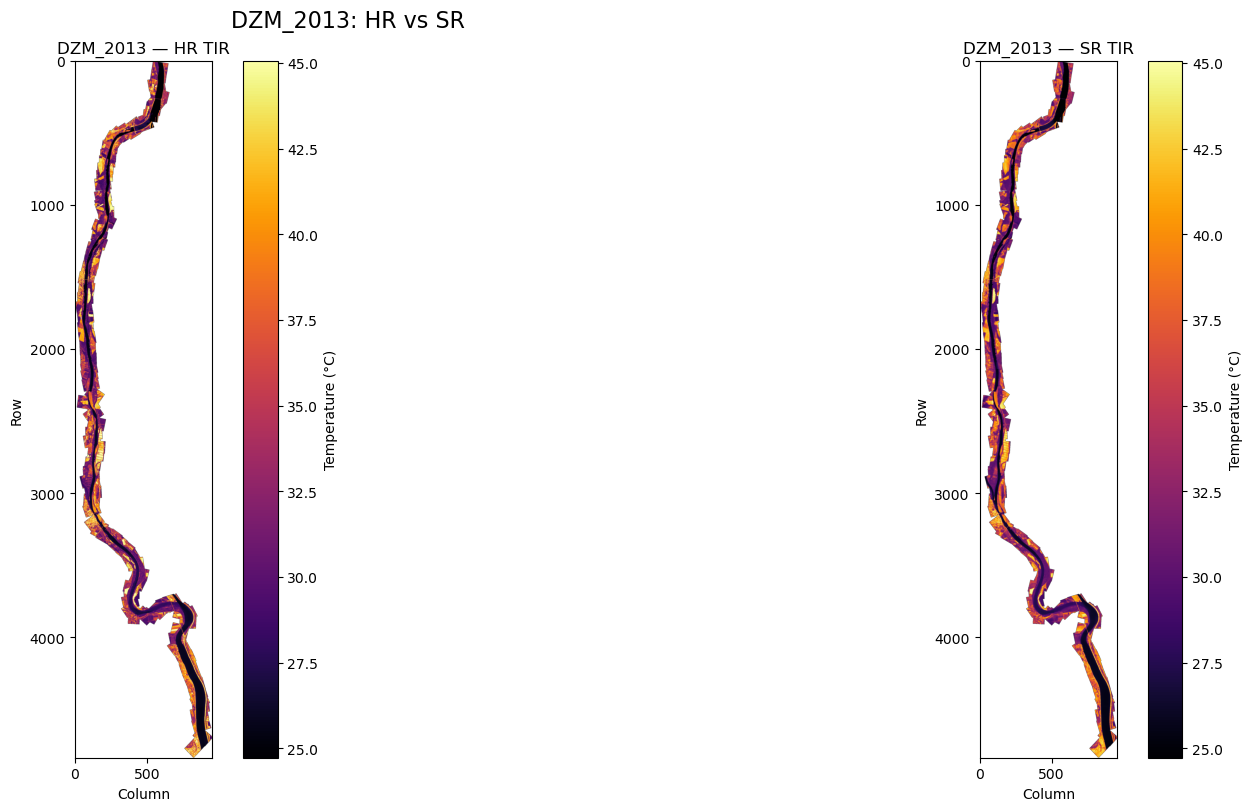

In [22]:

import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================================
# Paths
# ============================================================

BASE = Path("/share/home/e2406751/Superresolution-TIR")
CAMPAIGN = "DZM_2013"

HR_PATH = (
    BASE
    / "data/HR_downsampled"
    / f"{CAMPAIGN}.tif"
)

SR_PATH = (
    BASE
    / "data/inference_tiles"
    / CAMPAIGN
    / "SR_mosaic"
    / f"{CAMPAIGN}_SR.tif"
)


# ============================================================
# Load HR
# ============================================================

with rasterio.open(HR_PATH) as src:
    hr = src.read(1).astype(np.float32)
    hr_nodata = src.nodata

print("HR nodata:", hr_nodata)

# Build valid-data mask
if hr_nodata is not None:
    hr_valid_mask = hr != hr_nodata
else:
    hr_valid_mask = np.isfinite(hr)

# Also remove NaN / Inf
hr_valid_mask &= np.isfinite(hr)

# Mask invalid HR pixels
hr = np.where(hr_valid_mask, hr, np.nan)


# ============================================================
# Load SR
# ============================================================

with rasterio.open(SR_PATH) as src:
    sr = src.read(1).astype(np.float32)

sr_valid = np.isfinite(sr)

# Apply HR valid-data mask to SR
# This removes SR predictions where the original HR
# airborne TIR image has no valid observation.
sr_masked = np.where(
    hr_valid_mask & sr_valid,
    sr,
    np.nan
)


# ============================================================
# Common visualization range
# ============================================================

# Calculate range from VALID HR pixels only
vmin = np.nanpercentile(hr, 2)
vmax = np.nanpercentile(hr, 98)

print("\nVisualization range:")
print("  vmin:", vmin)
print("  vmax:", vmax)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    constrained_layout=True
)


# ============================================================
# HR
# ============================================================

im1 = axes[0].imshow(
    hr,
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)

axes[0].set_title(f"{CAMPAIGN} — HR TIR")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")

# HR colorbar
cbar1 = fig.colorbar(
    im1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)

cbar1.set_label("Temperature (°C)")


# ============================================================
# SR
# ============================================================

im2 = axes[1].imshow(
    sr_masked,
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title(f"{CAMPAIGN} — SR TIR")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")

# SR colorbar
cbar2 = fig.colorbar(
    im2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)

cbar2.set_label("Temperature (°C)")


# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    f"{CAMPAIGN}: HR vs SR",
    fontsize=16
)

plt.show()
